# Climate Analysis - WorldClim Dataset

## Analysis Structure

**Section 0: Setup & Imports**
- Configure multi-threading
- Import required libraries
- Define helper functions

**Section 1: Initial Data Loading**
- Load country boundaries (Algeria & Tunisia)
- Load climate raster files (precipitation, tmax, tmin)
- Display dataset summary

**Section 2: Initial EDA (Before Clipping)**
- Understand raster structure (CRS, resolution, bounds)
- Check temporal coverage
- Sample visualizations

**Section 3: Spatial Operations**
- Clip rasters to country boundaries
- Verify clipping results
- Visualize clipped data

**Section 4: Comprehensive EDA on Climate Data**
- Descriptive statistics
- Univariate analysis (Histograms, Boxplots)
- Bivariate analysis (Correlation matrix, Scatter plots)
- Temporal analysis (Trends, Seasonality)

**Section 5: Fire Points Integration**
- Load fire point locations
- Extract climate values at fire coordinates
- Aggregate by season

**Section 6: Data Preprocessing**
- Drop duplicates
- Handle missing values
- Detect and handle outliers
- Normalize features

**Section 7: Save Results**
- Save merged fire-climate dataset
- Generate summary

---
## Section 0: Setup & Imports

In [23]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import configure_threading

configure_threading()

Threading configured to use up to 12 CPU cores.


12

---
## Section 1: Initial Data Loading

### 1.1 Load Country Boundaries

In [24]:
# Import config and standard libraries
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.mask import mask
from rasterio.transform import rowcol
import geopandas as gpd
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Set plot style - consistent with other notebooks
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style='whitegrid')
sns.set_palette('husl')

# Custom color palette for climate variables
COLORS = {
    'prec': '#3498db',      # Blue for precipitation
    'tmax': '#e74c3c',      # Red for max temperature  
    'tmin': '#1abc9c',      # Teal for min temperature
    'fire': '#e67e22',      # Orange for fire points
    'no_fire': '#2ecc71',   # Green for non-fire points
    'algeria': '#9b59b6',   # Purple for Algeria
    'tunisia': '#f39c12'    # Gold for Tunisia
}

print("✅ Libraries imported and paths loaded from config")

✅ Libraries imported and paths loaded from config


✓ Algeria loaded - CRS: EPSG:4326, Polygons: 386454
✓ Tunisia loaded - CRS: EPSG:4326, Polygons: 52059
✓ Combined boundaries: 2 polygons


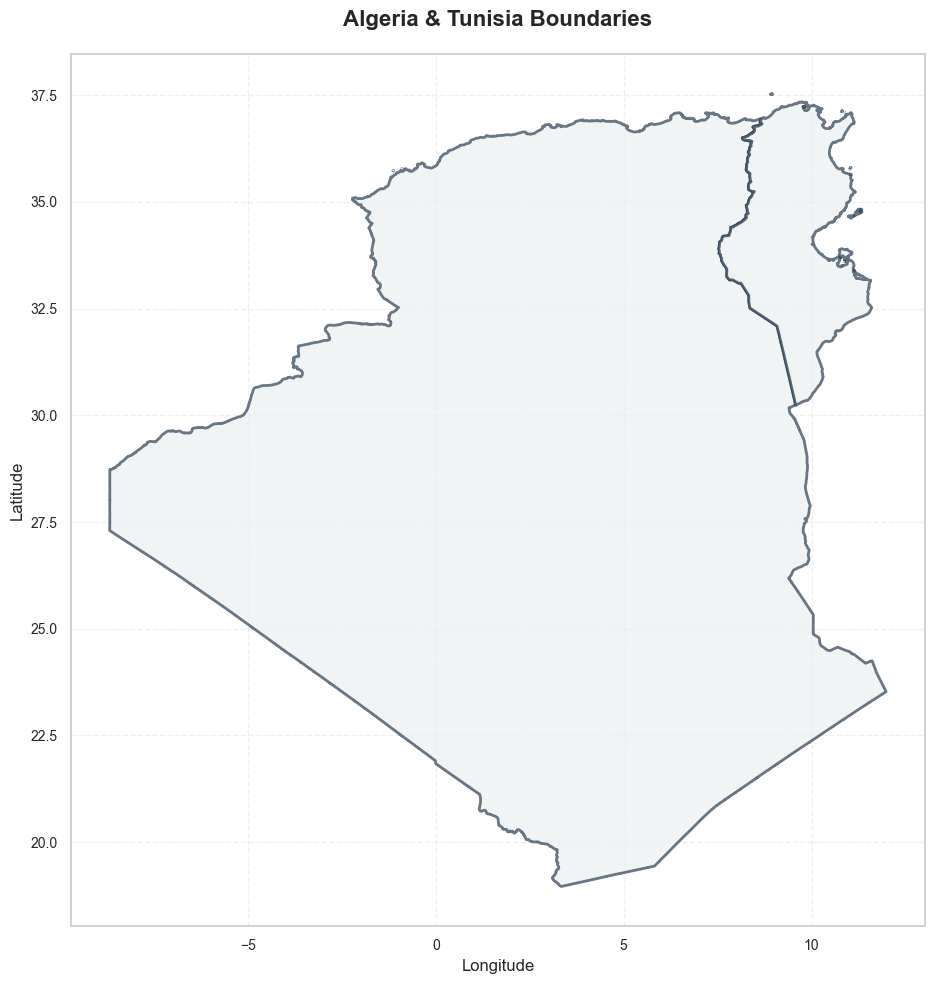

In [25]:
# Load country boundaries
def load_country_boundaries():
    """Load and combine Algeria and Tunisia boundaries."""
    if not ALGERIA_SHP.exists():
        raise FileNotFoundError(f"Algeria shapefile not found: {ALGERIA_SHP}")
    if not TUNISIA_SHP.exists():
        raise FileNotFoundError(f"Tunisia shapefile not found: {TUNISIA_SHP}")
    
    algeria = gpd.read_file(ALGERIA_SHP)
    tunisia = gpd.read_file(TUNISIA_SHP)
    
    print(f"✓ Algeria loaded - CRS: {algeria.crs}, Polygons: {len(algeria)}")
    print(f"✓ Tunisia loaded - CRS: {tunisia.crs}, Polygons: {len(tunisia)}")
    
    # Ensure same CRS
    if tunisia.crs != algeria.crs:
        tunisia = tunisia.to_crs(algeria.crs)
    
    # Dissolve polygons into single boundaries
    algeria_dissolved = algeria.dissolve().reset_index(drop=True)
    tunisia_dissolved = tunisia.dissolve().reset_index(drop=True)
    
    # Combine boundaries
    boundaries = pd.concat([algeria_dissolved, tunisia_dissolved], ignore_index=True)
    print(f"✓ Combined boundaries: {len(boundaries)} polygons")
    
    return boundaries

boundaries = load_country_boundaries()

# Visualize boundaries with nice styling
fig, ax = plt.subplots(figsize=(12, 10))
boundaries.plot(ax=ax, edgecolor='#2c3e50', facecolor='#ecf0f1', linewidth=2, alpha=0.7)
ax.set_title('Algeria & Tunisia Boundaries', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.tick_params(labelsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### 1.2 Load Climate Raster Files

**WorldClim Dataset:**
- Precipitation (prec): Monthly precipitation in mm
- Maximum Temperature (tmax): Monthly max temp in °C × 10
- Minimum Temperature (tmin): Monthly min temp in °C × 10
- Resolution: 5 arc-minutes (~10km at equator)

In [26]:
# Load raster files and extract dates
def get_all_rasters(directory):
    """Get all raster files from a directory."""
    if not directory.exists():
        print(f"⚠️ Directory not found: {directory}")
        return []
    return sorted(list(directory.glob('*.tif')) + list(directory.glob('*.TIF')))

def extract_date_from_filename(filename):
    """Extract date from filename pattern like 'wc2.1_cruts4.09_5m_TYPE_YYYY-MM.tif'"""
    try:
        name = filename.stem
        date_part = name.split('_')[-1]
        year, month = date_part.split('-')
        return pd.to_datetime(f"{year}-{month}-01")
    except:
        return None

# Load raster files
prec_files = get_all_rasters(PREC_DIR)
tmax_files = get_all_rasters(TMAX_DIR)
tmin_files = get_all_rasters(TMIN_DIR)

print(f"✓ Precipitation files: {len(prec_files)}")
print(f"✓ Max Temperature files: {len(tmax_files)}")
print(f"✓ Min Temperature files: {len(tmin_files)}")

# Create date mappings
prec_map = {extract_date_from_filename(Path(f)): f for f in prec_files if extract_date_from_filename(Path(f))}
tmax_map = {extract_date_from_filename(Path(f)): f for f in tmax_files if extract_date_from_filename(Path(f))}
tmin_map = {extract_date_from_filename(Path(f)): f for f in tmin_files if extract_date_from_filename(Path(f))}

# Find common dates
common_dates = sorted(list(set(prec_map.keys()) & set(tmax_map.keys()) & set(tmin_map.keys())))

print(f"\n✓ Common dates across all variables: {len(common_dates)}")
if common_dates:
    print(f"  Date range: {min(common_dates).strftime('%Y-%m')} → {max(common_dates).strftime('%Y-%m')}")

✓ Precipitation files: 120
✓ Max Temperature files: 120
✓ Min Temperature files: 120

✓ Common dates across all variables: 60
  Date range: 2020-01 → 2024-12


---
## Section 2: Initial EDA (Before Clipping)

### 2.1 Raster Structure Analysis

In [27]:
# Analyze raster structure
def analyze_raster_structure(raster_file, name):
    """Display structure information for a raster file."""
    with rasterio.open(raster_file) as src:
        data = src.read(1)
        if src.nodata is not None:
            data = np.ma.masked_equal(data, src.nodata)
        
        print(f"\n{'='*50}")
        print(f" {name}")
        print(f"{'='*50}")
        print(f"  CRS: {src.crs}")
        print(f"  Dimensions: {src.width} × {src.height} pixels")
        print(f"  Resolution: {src.res}")
        print(f"  NoData: {src.nodata}")
        print(f"\n  Statistics:")
        print(f"    Min: {np.ma.min(data):.2f}")
        print(f"    Max: {np.ma.max(data):.2f}")
        print(f"    Mean: {np.ma.mean(data):.2f}")
        print(f"    Valid pixels: {np.ma.count(data):,}")

# Analyze sample files
if prec_files:
    analyze_raster_structure(prec_files[0], "PRECIPITATION")
if tmax_files:
    analyze_raster_structure(tmax_files[0], "MAX TEMPERATURE")
if tmin_files:
    analyze_raster_structure(tmin_files[0], "MIN TEMPERATURE")


 PRECIPITATION
  CRS: EPSG:4326
  Dimensions: 4320 × 2160 pixels
  Resolution: (0.08333333333333333, 0.08333333333333333)
  NoData: nan

  Statistics:
    Min: nan
    Max: nan
    Mean: nan
    Valid pixels: 9,331,200

 MAX TEMPERATURE
  CRS: EPSG:4326
  Dimensions: 4320 × 2160 pixels
  Resolution: (0.08333333333333333, 0.08333333333333333)
  NoData: nan

  Statistics:
    Min: nan
    Max: nan
    Mean: nan
    Valid pixels: 9,331,200

 MIN TEMPERATURE
  CRS: EPSG:4326
  Dimensions: 4320 × 2160 pixels
  Resolution: (0.08333333333333333, 0.08333333333333333)
  NoData: nan

  Statistics:
    Min: nan
    Max: nan
    Mean: nan
    Valid pixels: 9,331,200


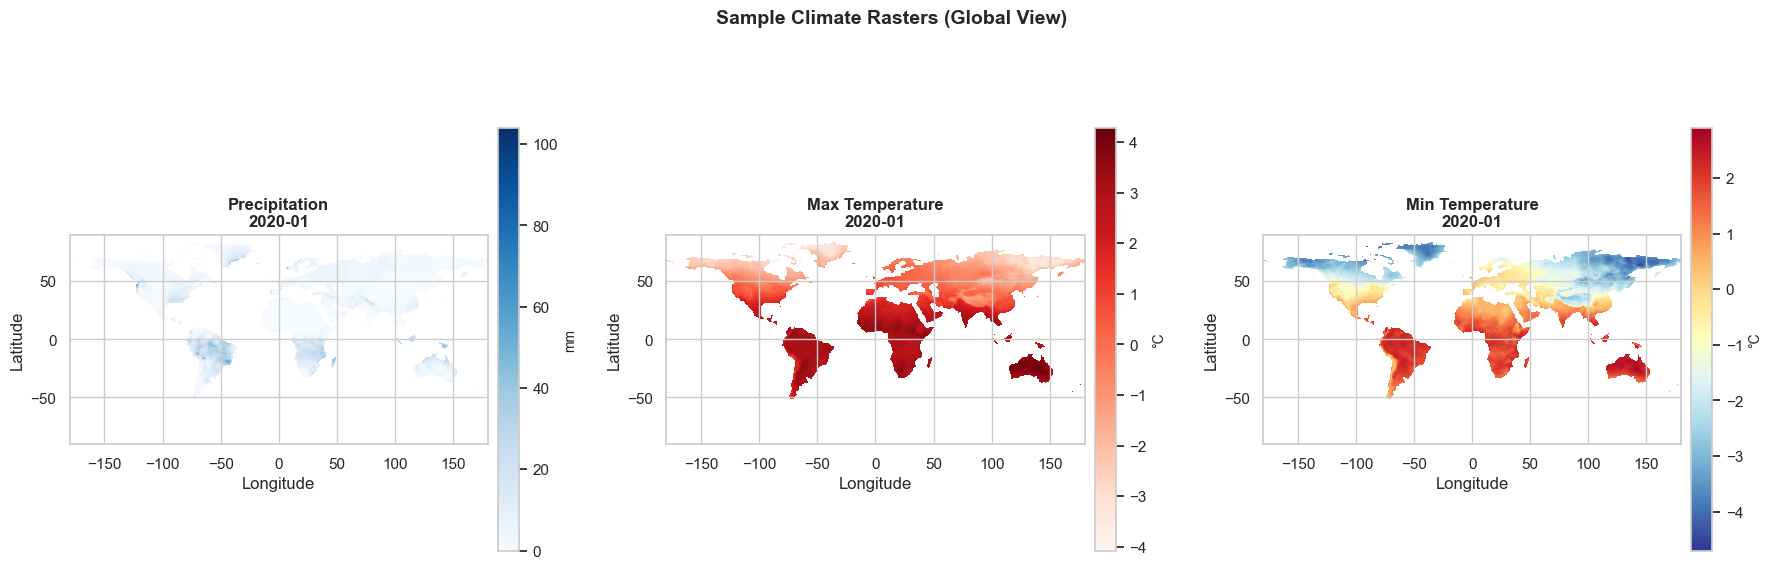

In [28]:
# Visualize sample rasters (before clipping)
if common_dates:
    sample_date = common_dates[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    variables = [
        (prec_map[sample_date], 'Precipitation', 'Blues', 0.1, 'mm'),
        (tmax_map[sample_date], 'Max Temperature', 'Reds', 0.1, '°C'),
        (tmin_map[sample_date], 'Min Temperature', 'RdYlBu_r', 0.1, '°C')
    ]
    
    for ax, (raster_path, title, cmap, mult, unit) in zip(axes, variables):
        with rasterio.open(raster_path) as src:
            data = src.read(1)
            if src.nodata is not None:
                data = np.ma.masked_equal(data, src.nodata)
            data = data * mult
            
            im = ax.imshow(data, cmap=cmap, 
                          extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])
            cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
            cbar.set_label(unit, fontsize=10)
            ax.set_title(f'{title}\n{sample_date.strftime("%Y-%m")}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')
    
    plt.suptitle('Sample Climate Rasters (Global View)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

---
## Section 3: Spatial Operations

### 3.1 Clip Rasters to Country Boundaries

In [29]:
# Clip rasters to country boundaries with caching
def clip_raster_to_boundaries(raster_path, boundaries):
    """Clip a raster to country boundaries."""
    with rasterio.open(raster_path) as src:
        boundaries_proj = boundaries.to_crs(src.crs) if boundaries.crs != src.crs else boundaries
        out_image, out_transform = mask(src, boundaries_proj.geometry, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        return out_image[0], out_transform, out_meta

def clip_single_date(date, prec_path, tmax_path, tmin_path, boundaries):
    """Clip all three variables for a single date."""
    results = {}
    try:
        prec_data, prec_transform, prec_meta = clip_raster_to_boundaries(prec_path, boundaries)
        results['prec'] = (date, prec_data, prec_transform, prec_meta)
    except Exception as e:
        results['prec'] = (date, None, None, None)
    
    try:
        tmax_data, tmax_transform, tmax_meta = clip_raster_to_boundaries(tmax_path, boundaries)
        results['tmax'] = (date, tmax_data, tmax_transform, tmax_meta)
    except Exception as e:
        results['tmax'] = (date, None, None, None)
    
    try:
        tmin_data, tmin_transform, tmin_meta = clip_raster_to_boundaries(tmin_path, boundaries)
        results['tmin'] = (date, tmin_data, tmin_transform, tmin_meta)
    except Exception as e:
        results['tmin'] = (date, None, None, None)
    
    return results

# Cache file path
CLIPPED_DIR = RESULTS_DIR / 'clipped_rasters'
CLIPPED_DIR.mkdir(parents=True, exist_ok=True)
cache_file = CLIPPED_DIR / 'clipped_cache.pkl'

# Try to load from cache
cache_loaded = False
if cache_file.exists():
    print("📦 Loading clipped data from cache...")
    try:
        with open(cache_file, 'rb') as f:
            cached_data = pickle.load(f)
            clipped_prec = cached_data['prec']
            clipped_tmax = cached_data['tmax']
            clipped_tmin = cached_data['tmin']
        print(f"✓ Loaded {len(clipped_prec)} precipitation rasters")
        print(f"✓ Loaded {len(clipped_tmax)} max temperature rasters")
        print(f"✓ Loaded {len(clipped_tmin)} min temperature rasters")
        cache_loaded = True
    except (ModuleNotFoundError, AttributeError, ImportError) as e:
        print(f"⚠️ Cache incompatible with current environment: {e}")
        print("   Deleting old cache and regenerating...")
        cache_file.unlink()
        cache_loaded = False

if not cache_loaded:
    print(f"🔧 Clipping {len(common_dates)} dates using parallel processing...")
    
    clipped_prec, clipped_tmax, clipped_tmin = {}, {}, {}
    max_workers = max(1, multiprocessing.cpu_count() - 1)
    lock = threading.Lock()
    start_time = time.time()
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(clip_single_date, date, prec_map[date], tmax_map[date], 
                                   tmin_map[date], boundaries): date for date in common_dates}
        
        for i, future in enumerate(as_completed(futures), 1):
            results = future.result()
            with lock:
                if results['prec'][1] is not None:
                    clipped_prec[results['prec'][0]] = results['prec'][1:]
                if results['tmax'][1] is not None:
                    clipped_tmax[results['tmax'][0]] = results['tmax'][1:]
                if results['tmin'][1] is not None:
                    clipped_tmin[results['tmin'][0]] = results['tmin'][1:]
            
            if i % 20 == 0 or i == len(common_dates):
                print(f"  Progress: {i}/{len(common_dates)} ({100*i/len(common_dates):.0f}%)")
    
    print(f"\n✓ Clipping complete in {time.time() - start_time:.1f}s")
    
    # Save to cache
    with open(cache_file, 'wb') as f:
        pickle.dump({'prec': clipped_prec, 'tmax': clipped_tmax, 'tmin': clipped_tmin}, f)
    print(f"✓ Cache saved to {cache_file}")

📦 Loading clipped data from cache...
✓ Loaded 60 precipitation rasters
✓ Loaded 60 max temperature rasters
✓ Loaded 60 min temperature rasters


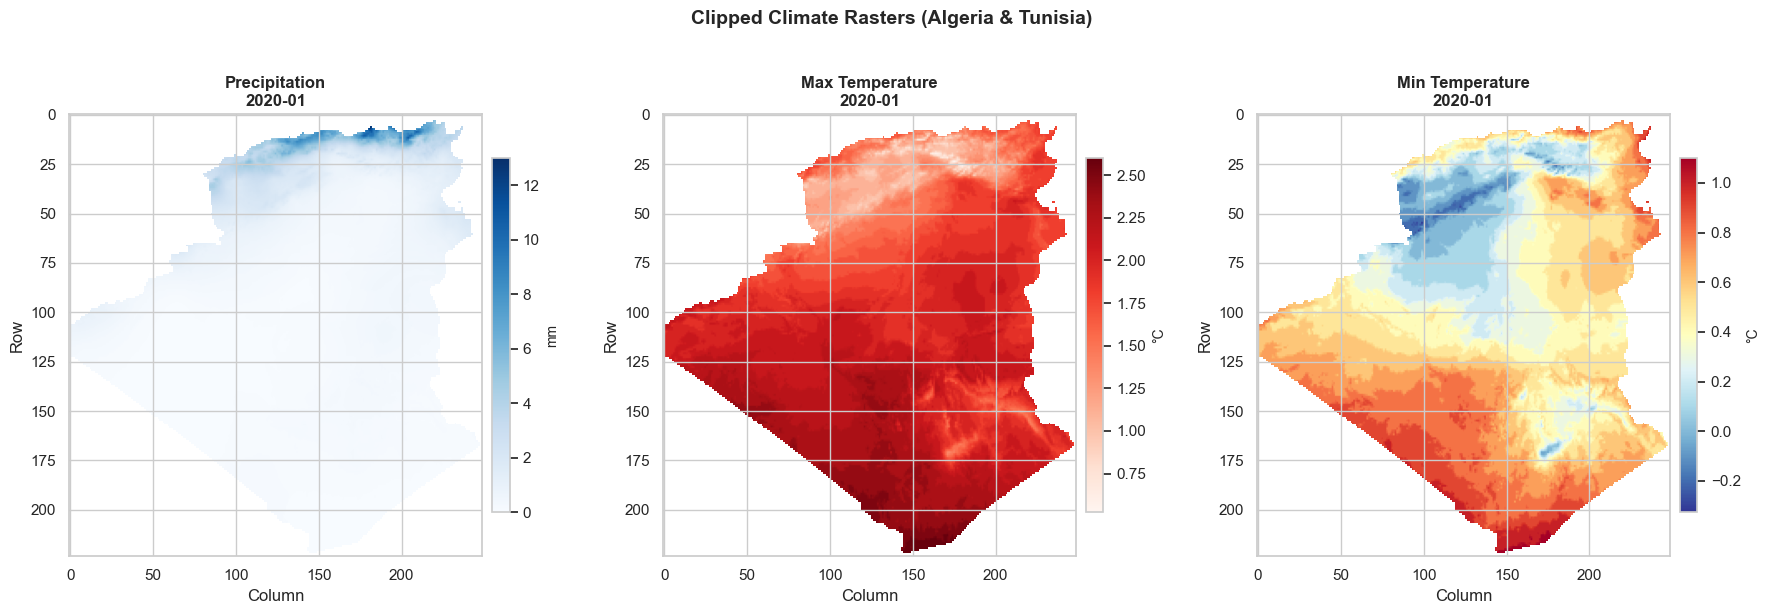

✓ Clipping verified - Shape: (224, 249)


In [30]:
# Visualize clipped rasters
if common_dates:
    sample_date = common_dates[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    datasets = [
        (clipped_prec[sample_date], 'Precipitation', 'Blues', 'mm'),
        (clipped_tmax[sample_date], 'Max Temperature', 'Reds', '°C'),
        (clipped_tmin[sample_date], 'Min Temperature', 'RdYlBu_r', '°C')
    ]
    
    for ax, ((data, transform, meta), title, cmap, unit) in zip(axes, datasets):
        data_masked = np.ma.masked_invalid(data) * 0.1
        im = ax.imshow(data_masked, cmap=cmap, aspect='auto')
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label(unit, fontsize=10)
        ax.set_title(f'{title}\n{sample_date.strftime("%Y-%m")}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
    
    plt.suptitle('Clipped Climate Rasters (Algeria & Tunisia)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Clipping verified - Shape: {clipped_prec[sample_date][0].shape}")

---
## Section 4: Comprehensive EDA on Climate Data

### 4.1 Descriptive Statistics

In [31]:
# Calculate descriptive statistics for clipped data
def calculate_statistics(clipped_data_dict, multiplier=0.1):
    """Calculate statistics for all clipped rasters."""
    stats_list = []
    for date, (data, transform, meta) in clipped_data_dict.items():
        data_masked = np.ma.masked_invalid(data) * multiplier
        stats_list.append({
            'date': date,
            'min': float(np.ma.min(data_masked)),
            'max': float(np.ma.max(data_masked)),
            'mean': float(np.ma.mean(data_masked)),
            'median': float(np.ma.median(data_masked)),
            'std': float(np.ma.std(data_masked)),
            'valid_pixels': int(np.ma.count(data_masked))
        })
    return pd.DataFrame(stats_list).sort_values('date')

# Calculate statistics
prec_stats = calculate_statistics(clipped_prec)
tmax_stats = calculate_statistics(clipped_tmax)
tmin_stats = calculate_statistics(clipped_tmin)

# Display summary
print("📊 Climate Statistics Summary")
print("=" * 60)

for name, stats in [('Precipitation', prec_stats), ('Max Temperature', tmax_stats), ('Min Temperature', tmin_stats)]:
    print(f"\n{name}:")
    print(f"  Mean range: {stats['mean'].min():.2f} - {stats['mean'].max():.2f}")
    print(f"  Overall mean: {stats['mean'].mean():.2f}")
    print(f"  Overall std: {stats['std'].mean():.2f}")

📊 Climate Statistics Summary

Precipitation:
  Mean range: 0.09 - 1.59
  Overall mean: 0.55
  Overall std: 1.07

Max Temperature:
  Mean range: 1.85 - 4.22
  Overall mean: 3.11
  Overall std: 0.40

Min Temperature:
  Mean range: 0.50 - 2.73
  Overall mean: 1.66
  Overall std: 0.30


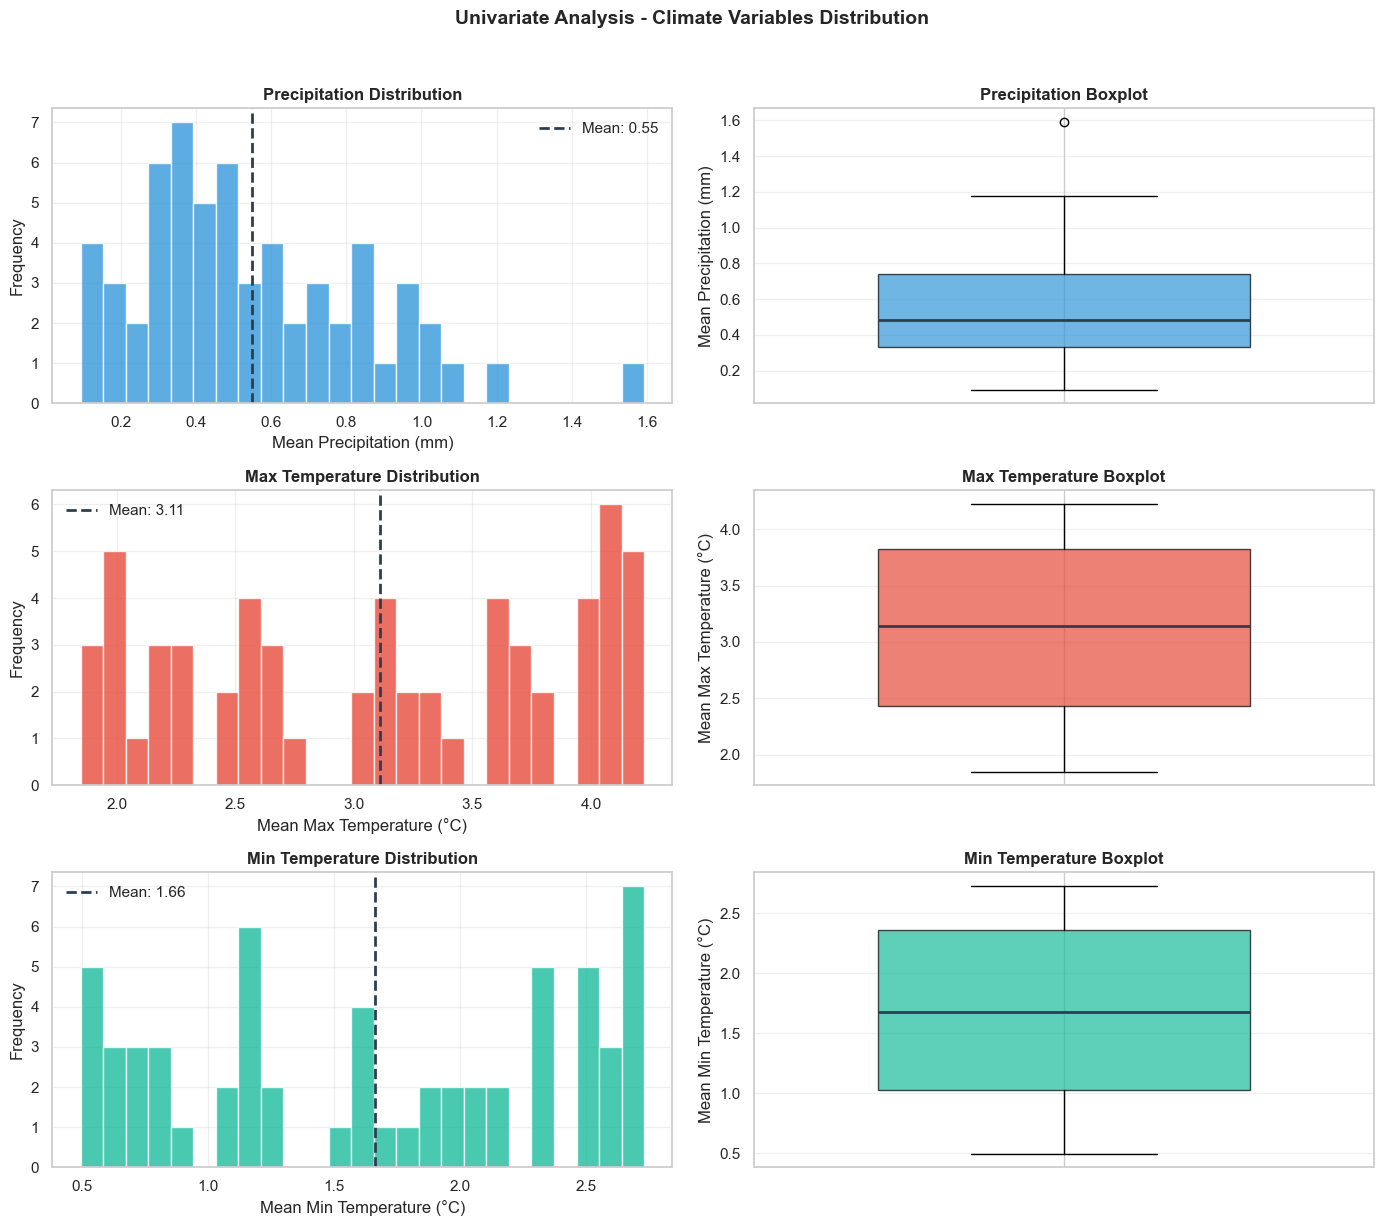

In [32]:
# Univariate Analysis - Distributions with nice styling
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

datasets = [
    (prec_stats['mean'], 'Precipitation', COLORS['prec'], 'mm'),
    (tmax_stats['mean'], 'Max Temperature', COLORS['tmax'], '°C'),
    (tmin_stats['mean'], 'Min Temperature', COLORS['tmin'], '°C')
]

for i, (data, title, color, unit) in enumerate(datasets):
    # Histogram
    axes[i, 0].hist(data, bins=25, edgecolor='white', color=color, alpha=0.8)
    axes[i, 0].axvline(data.mean(), color='#2c3e50', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
    axes[i, 0].set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(f'Mean {title} ({unit})')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)
    
    # Boxplot
    bp = axes[i, 1].boxplot(data, patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    bp['medians'][0].set_color('#2c3e50')
    bp['medians'][0].set_linewidth(2)
    axes[i, 1].set_title(f'{title} Boxplot', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel(f'Mean {title} ({unit})')
    axes[i, 1].set_xticklabels([''])
    axes[i, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Univariate Analysis - Climate Variables Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

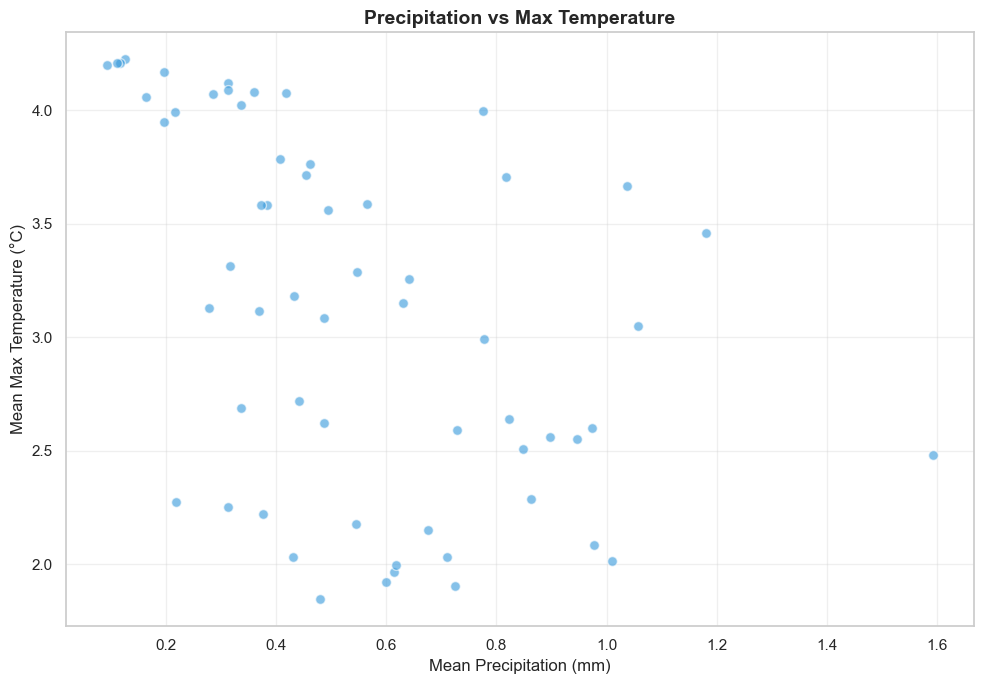

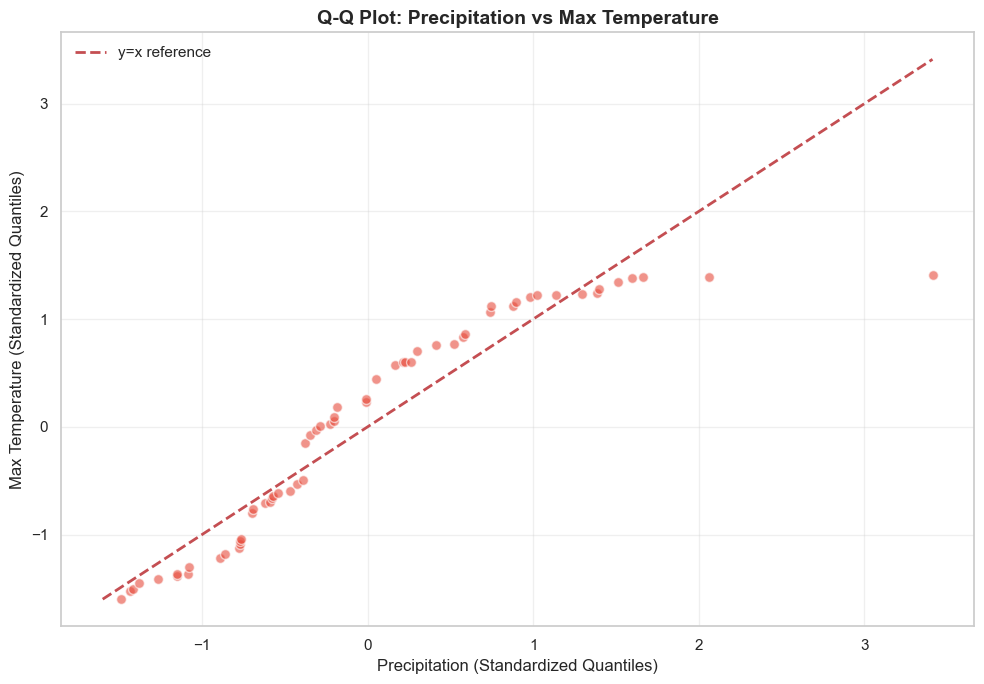


📊 Correlation between Precipitation and Max Temperature: -0.472


In [33]:
# Bivariate Analysis - Precipitation vs Temperature
from scipy import stats as sp_stats

combined_stats = pd.DataFrame({
    'date': prec_stats['date'],
    'Precipitation': prec_stats['mean'],
    'Max Temperature': tmax_stats['mean'],
    'Min Temperature': tmin_stats['mean']
})

# Figure 1: Scatter Plot - Precipitation vs Max Temperature
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(combined_stats['Precipitation'], combined_stats['Max Temperature'], 
           alpha=0.6, c=COLORS['prec'], s=50, edgecolor='white')
ax.set_xlabel('Mean Precipitation (mm)', fontsize=12)
ax.set_ylabel('Mean Max Temperature (°C)', fontsize=12)
ax.set_title('Precipitation vs Max Temperature', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Q-Q Plot - Precipitation vs Max Temperature
fig, ax = plt.subplots(figsize=(10, 7))

# Standardize both variables
prec_standardized = (combined_stats['Precipitation'] - combined_stats['Precipitation'].mean()) / combined_stats['Precipitation'].std()
tmax_standardized = (combined_stats['Max Temperature'] - combined_stats['Max Temperature'].mean()) / combined_stats['Max Temperature'].std()

# Sort both for Q-Q plot
prec_sorted = np.sort(prec_standardized)
tmax_sorted = np.sort(tmax_standardized)

ax.scatter(prec_sorted, tmax_sorted, alpha=0.6, c=COLORS['tmax'], s=50, edgecolor='white')
# Add diagonal reference line
min_val = min(prec_sorted.min(), tmax_sorted.min())
max_val = max(prec_sorted.max(), tmax_sorted.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x reference')
ax.set_xlabel('Precipitation (Standardized Quantiles)', fontsize=12)
ax.set_ylabel('Max Temperature (Standardized Quantiles)', fontsize=12)
ax.set_title('Q-Q Plot: Precipitation vs Max Temperature', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate and display correlation
correlation = combined_stats['Precipitation'].corr(combined_stats['Max Temperature'])
print(f"\n📊 Correlation between Precipitation and Max Temperature: {correlation:.3f}")

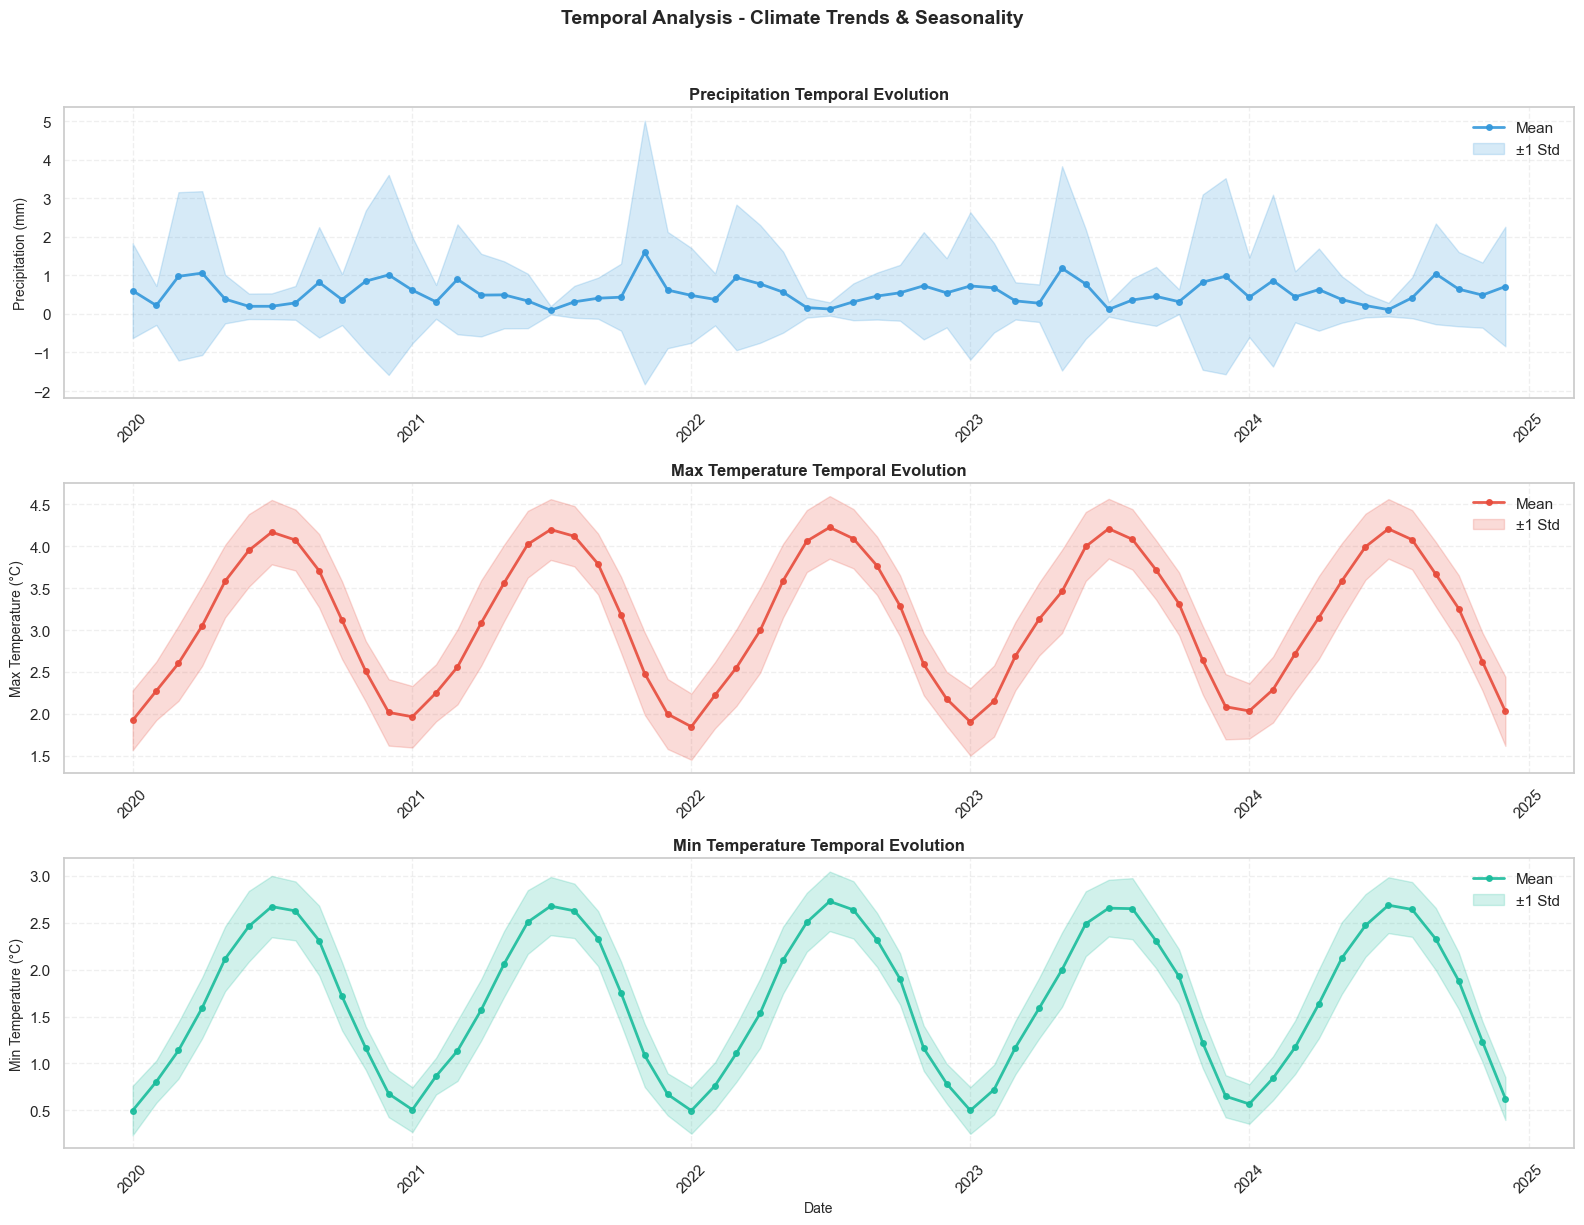

In [34]:
# Temporal Analysis - Trends & Seasonality
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

datasets = [
    (prec_stats, 'Precipitation', COLORS['prec'], 'mm'),
    (tmax_stats, 'Max Temperature', COLORS['tmax'], '°C'),
    (tmin_stats, 'Min Temperature', COLORS['tmin'], '°C')
]

for ax, (stats, title, color, unit) in zip(axes, datasets):
    ax.plot(stats['date'], stats['mean'], marker='o', markersize=4, color=color, 
            linewidth=2, label='Mean', alpha=0.9)
    ax.fill_between(stats['date'], 
                    stats['mean'] - stats['std'], 
                    stats['mean'] + stats['std'], 
                    alpha=0.2, color=color, label='±1 Std')
    ax.set_title(f'{title} Temporal Evolution', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{title} ({unit})', fontsize=10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_xlabel('Date', fontsize=10)
plt.suptitle('Temporal Analysis - Climate Trends & Seasonality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 5: Fire Points Integration

### 5.1 Load Fire Points Data

In [49]:
# Load fire point locations using config paths
fires_df = pd.read_csv(FIRES_WITH_ARTIFICIAL)

fires_df_original = fires_df.copy()  # Keep original for comparison

print(f"✓ Loaded {len(fires_df)} fire points")
print(f"  Columns: {list(fires_df.columns)}")
print(f"\n📊 Class Distribution:")
print(fires_df['class'].value_counts())

# Convert to GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326'
)

print(f"\n✓ GeoDataFrame created")
print(f"  CRS: {fires_gdf.crs}")
print(f"  Bounds: [{fires_df['longitude'].min():.2f}, {fires_df['latitude'].min():.2f}] → [{fires_df['longitude'].max():.2f}, {fires_df['latitude'].max():.2f}]")

✓ Loaded 8212 fire points
  Columns: ['longitude', 'latitude', 'class']

📊 Class Distribution:
class
0    4927
1    3285
Name: count, dtype: int64

✓ GeoDataFrame created
  CRS: EPSG:4326
  Bounds: [-2.18, 33.02] → [11.11, 37.32]


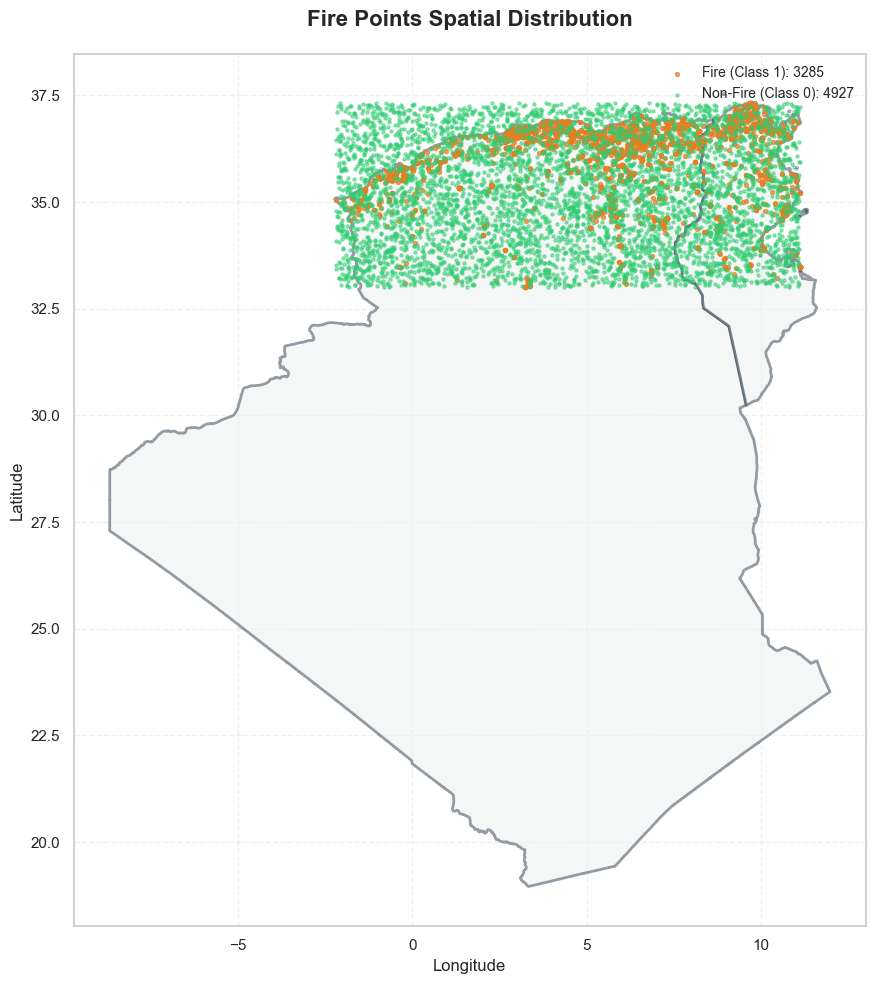

In [50]:
# Visualize fire points spatial distribution
fig, ax = plt.subplots(figsize=(14, 10))

# Plot boundaries
boundaries.plot(ax=ax, edgecolor='#2c3e50', facecolor='#ecf0f1', linewidth=2, alpha=0.5)

# Plot fire points by class
fires_class_1 = fires_gdf[fires_gdf['class'] == 1]
fires_class_0 = fires_gdf[fires_gdf['class'] == 0]

if len(fires_class_1) > 0:
    fires_class_1.plot(ax=ax, markersize=8, color=COLORS['fire'], 
                       alpha=0.7, label=f'Fire (Class 1): {len(fires_class_1)}', marker='o')

if len(fires_class_0) > 0:
    fires_class_0.plot(ax=ax, markersize=5, color=COLORS['no_fire'], 
                       alpha=0.5, label=f'Non-Fire (Class 0): {len(fires_class_0)}', marker='o')

ax.set_title('Fire Points Spatial Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


### 5.2 Extract Climate Values at Fire Locations

In [37]:
# Define seasons
def get_season(month):
    """Determine season from month number."""
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

# Extract climate values at fire points
def extract_climate_at_points(fires_df, clipped_data_dict, multiplier=0.1):
    """Extract climate values at fire point locations."""
    results = []
    for date, (data, transform, meta) in clipped_data_dict.items():
        values = []
        for lon, lat in zip(fires_df['longitude'], fires_df['latitude']):
            row, col = rowcol(transform, lon, lat)
            if 0 <= row < data.shape[0] and 0 <= col < data.shape[1]:
                value = data[row, col]
                if np.isnan(value) or (meta.get('nodata') and value == meta['nodata']):
                    values.append(np.nan)
                else:
                    values.append(value * multiplier)
            else:
                values.append(np.nan)
        results.append({'date': date, 'values': values})
    return results

print("⚡ Extracting climate values at fire locations...")
print(f"   Processing {len(fires_df)} points × {len(common_dates)} dates...\n")

prec_extractions = extract_climate_at_points(fires_df, clipped_prec)
print("✓ Precipitation extracted")

tmax_extractions = extract_climate_at_points(fires_df, clipped_tmax)
print("✓ Max temperature extracted")

tmin_extractions = extract_climate_at_points(fires_df, clipped_tmin)
print("✓ Min temperature extracted")

⚡ Extracting climate values at fire locations...
   Processing 8212 points × 60 dates...

✓ Precipitation extracted
✓ Max temperature extracted
✓ Min temperature extracted


In [38]:
# Aggregate by season
print("📊 Aggregating climate data by season...")

# Initialize seasonal columns
for season in ['winter', 'spring', 'summer', 'autumn']:
    fires_df[f'prec_{season}'] = 0.0
    fires_df[f'tmax_{season}'] = 0.0
    fires_df[f'tmin_{season}'] = 0.0

# Count dates per season
season_counts = {season: len([d for d in common_dates if get_season(d.month) == season]) 
                 for season in ['winter', 'spring', 'summer', 'autumn']}

# Aggregate values
for extraction in prec_extractions:
    season = get_season(extraction['date'].month)
    fires_df[f'prec_{season}'] += np.nan_to_num(extraction['values'], nan=0.0)

for extraction in tmax_extractions:
    season = get_season(extraction['date'].month)
    fires_df[f'tmax_{season}'] += np.nan_to_num(extraction['values'], nan=0.0)

for extraction in tmin_extractions:
    season = get_season(extraction['date'].month)
    fires_df[f'tmin_{season}'] += np.nan_to_num(extraction['values'], nan=0.0)

# Calculate averages
for season in ['winter', 'spring', 'summer', 'autumn']:
    if season_counts[season] > 0:
        fires_df[f'prec_{season}'] /= season_counts[season]
        fires_df[f'tmax_{season}'] /= season_counts[season]
        fires_df[f'tmin_{season}'] /= season_counts[season]

print("\n✓ Seasonal aggregation complete")
print(f"  Dates per season: {season_counts}")
print(f"  New columns: {[c for c in fires_df.columns if '_' in c and c.split('_')[0] in ['prec', 'tmax', 'tmin']]}")

📊 Aggregating climate data by season...

✓ Seasonal aggregation complete
  Dates per season: {'winter': 15, 'spring': 15, 'summer': 15, 'autumn': 15}
  New columns: ['prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn']


---
## Section 6: Data Preprocessing

### 6.1 Drop Duplicates & Handle Missing Values

In [39]:
# Data Preprocessing
print("🔧 Data Preprocessing")
print("=" * 60)

# Step 1: Drop duplicates
before_dup = len(fires_df)
fires_df = fires_df.drop_duplicates()
after_dup = len(fires_df)
print(f"\n1. Duplicates: Removed {before_dup - after_dup} rows")

# Step 2: Handle missing values
numeric_cols = fires_df.select_dtypes(include=[np.number]).columns.tolist()
climate_cols = [c for c in numeric_cols if c not in ['longitude', 'latitude', 'class']]

print(f"\n2. Missing Values:")
missing_before = fires_df[climate_cols].isnull().sum().sum()
print(f"   Before: {missing_before} missing values")

for col in climate_cols:
    if fires_df[col].isnull().sum() > 0:
        median_val = fires_df[col].median()
        fires_df[col].fillna(median_val, inplace=True)

missing_after = fires_df[climate_cols].isnull().sum().sum()
print(f"   After: {missing_after} missing values")

🔧 Data Preprocessing

1. Duplicates: Removed 0 rows

2. Missing Values:
   Before: 0 missing values
   After: 0 missing values


In [40]:
# Step 3: Detect and handle outliers using IQR method
print(f"\n3. Outlier Detection (IQR method):")

outlier_count_total = 0
for col in climate_cols:
    Q1, Q3 = fires_df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
    outliers_mask = (fires_df[col] < lower_bound) | (fires_df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        median_val = fires_df[col].median()
        fires_df.loc[outliers_mask, col] = median_val
        outlier_count_total += outliers_count

print(f"   Replaced {outlier_count_total} outliers across all climate columns")


3. Outlier Detection (IQR method):
   Replaced 7955 outliers across all climate columns


In [41]:
# Step 4: Normalize features
from sklearn.preprocessing import StandardScaler

print(f"\n4. Feature Normalization:")
print(f"   Normalizing {len(climate_cols)} climate columns")

scaler = StandardScaler()
fires_df[climate_cols] = scaler.fit_transform(fires_df[climate_cols])

print(f"   ✓ StandardScaler applied")

# Summary
print(f"\n{'=' * 60}")
print(f"✅ Preprocessing Complete")
print(f"   Final dataset shape: {fires_df.shape}")
print(f"   Rows retained: {len(fires_df)}/{len(fires_df_original)} ({100*len(fires_df)/len(fires_df_original):.1f}%)")


4. Feature Normalization:
   Normalizing 12 climate columns
   ✓ StandardScaler applied

✅ Preprocessing Complete
   Final dataset shape: (8212, 15)
   Rows retained: 8212/8212 (100.0%)


---
## Section 7: Save Results

In [42]:
# Save final merged dataset
output_file = FIRES_WITH_CLIMATE
fires_df.to_csv(output_file, index=False)

print(f"💾 Dataset saved to: {output_file}")
print(f"\n{'=' * 60}")
print("FINAL DATASET SUMMARY")
print(f"{'=' * 60}")
print(f"\nShape: {fires_df.shape}")
print(f"\nColumns:")
for col in fires_df.columns:
    print(f"  • {col}")

print(f"\nClass distribution:")
print(fires_df['class'].value_counts())

print(f"\nClimate features (first 5 rows):")
display(fires_df[['longitude', 'latitude', 'class'] + climate_cols[:6]].head())

💾 Dataset saved to: C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_climate.csv

FINAL DATASET SUMMARY

Shape: (8212, 15)

Columns:
  • longitude
  • latitude
  • class
  • prec_winter
  • tmax_winter
  • tmin_winter
  • prec_spring
  • tmax_spring
  • tmin_spring
  • prec_summer
  • tmax_summer
  • tmin_summer
  • prec_autumn
  • tmax_autumn
  • tmin_autumn

Class distribution:
class
0    4927
1    3285
Name: count, dtype: int64

Climate features (first 5 rows):


,longitude,latitude,class,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring
0,9.42603,37.00734,1,1.615200,0.194102,0.790541,1.039387,-0.496507,-0.128786
1,0.84846,36.48433,0,-1.028843,-0.228860,-1.672901,-1.340004,-0.279597,-0.251520
2,4.13116,36.62614,1,2.017645,-0.245513,0.644919,1.684295,-0.583271,0.224978
3,7.28408,36.89190,1,1.960318,0.806897,1.470111,0.818532,-0.267202,0.289955
4,8.46453,35.31460,0,-0.347940,-1.138063,-0.374437,0.247051,-0.539889,-0.836312


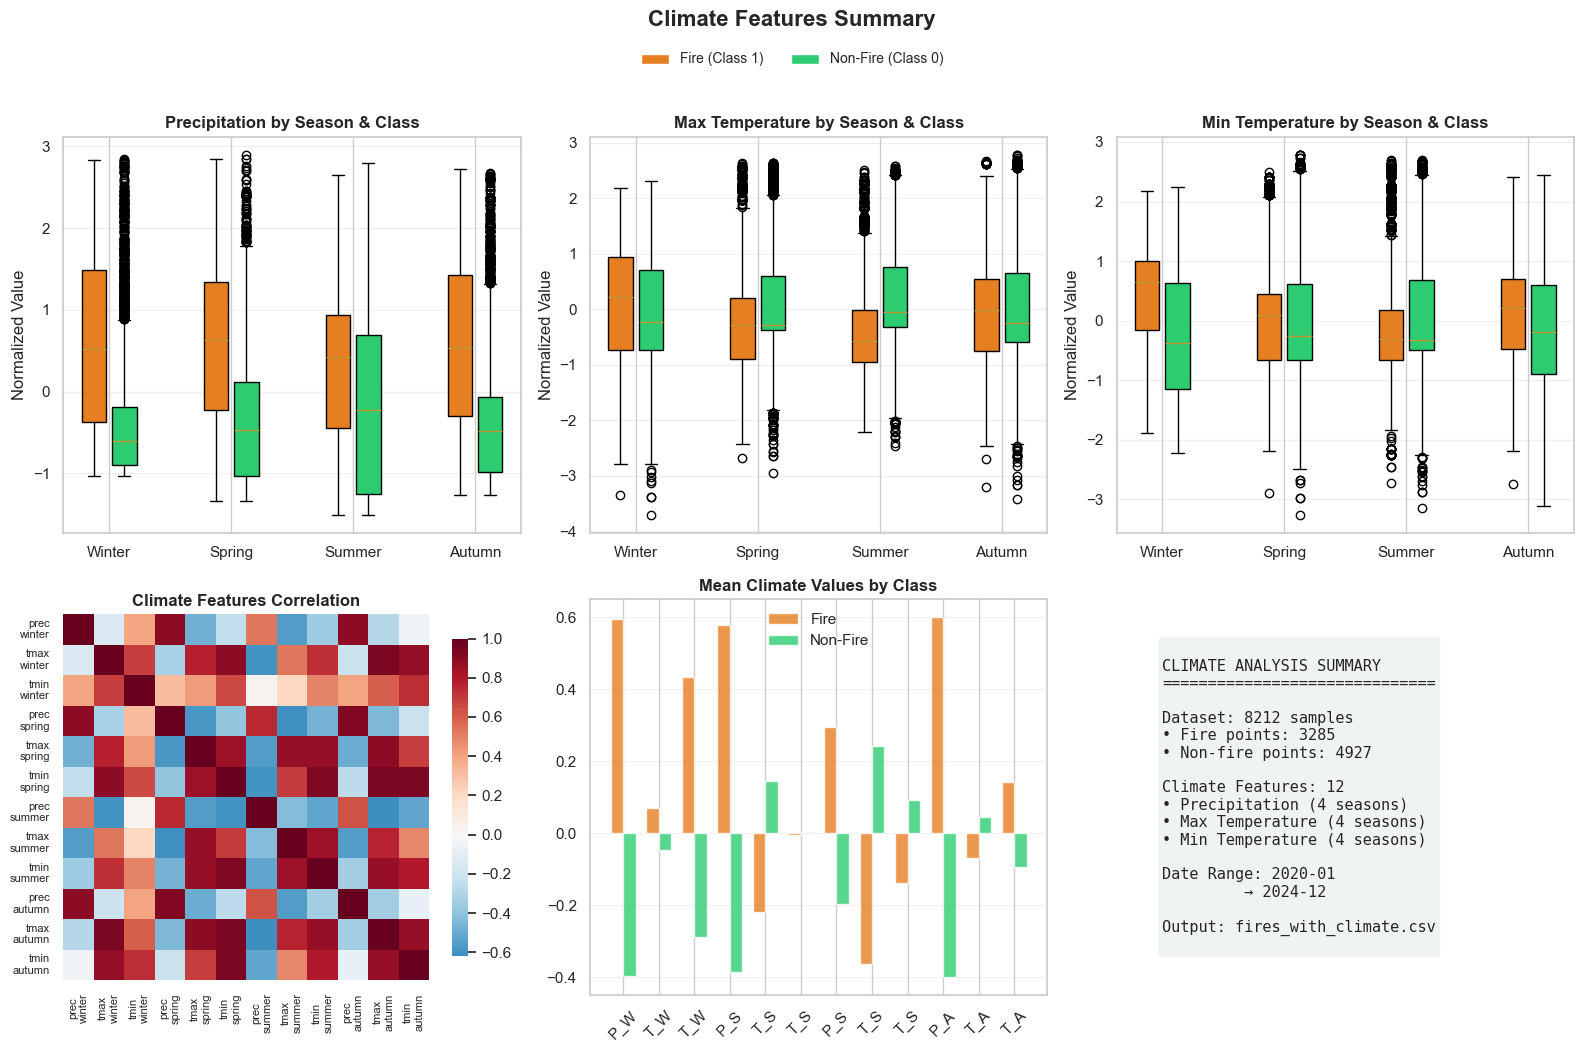


✅ Climate analysis complete!


In [43]:
# Final visualization - Climate features by class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

seasons = ['winter', 'spring', 'summer', 'autumn']
season_colors = {'winter': '#3498db', 'spring': '#2ecc71', 'summer': '#e74c3c', 'autumn': '#e67e22'}

# Precipitation by season
ax = axes[0, 0]
for i, season in enumerate(seasons):
    col = f'prec_{season}'
    fire_vals = fires_df[fires_df['class'] == 1][col]
    no_fire_vals = fires_df[fires_df['class'] == 0][col]
    bp1 = ax.boxplot([fire_vals], positions=[i*2], widths=0.4, patch_artist=True)
    bp2 = ax.boxplot([no_fire_vals], positions=[i*2+0.5], widths=0.4, patch_artist=True)
    bp1['boxes'][0].set_facecolor(COLORS['fire'])
    bp2['boxes'][0].set_facecolor(COLORS['no_fire'])
ax.set_xticks([i*2+0.25 for i in range(4)])
ax.set_xticklabels(['Winter', 'Spring', 'Summer', 'Autumn'])
ax.set_title('Precipitation by Season & Class', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.grid(True, alpha=0.3, axis='y')

# Max Temperature by season  
ax = axes[0, 1]
for i, season in enumerate(seasons):
    col = f'tmax_{season}'
    fire_vals = fires_df[fires_df['class'] == 1][col]
    no_fire_vals = fires_df[fires_df['class'] == 0][col]
    bp1 = ax.boxplot([fire_vals], positions=[i*2], widths=0.4, patch_artist=True)
    bp2 = ax.boxplot([no_fire_vals], positions=[i*2+0.5], widths=0.4, patch_artist=True)
    bp1['boxes'][0].set_facecolor(COLORS['fire'])
    bp2['boxes'][0].set_facecolor(COLORS['no_fire'])
ax.set_xticks([i*2+0.25 for i in range(4)])
ax.set_xticklabels(['Winter', 'Spring', 'Summer', 'Autumn'])
ax.set_title('Max Temperature by Season & Class', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.grid(True, alpha=0.3, axis='y')

# Min Temperature by season
ax = axes[0, 2]
for i, season in enumerate(seasons):
    col = f'tmin_{season}'
    fire_vals = fires_df[fires_df['class'] == 1][col]
    no_fire_vals = fires_df[fires_df['class'] == 0][col]
    bp1 = ax.boxplot([fire_vals], positions=[i*2], widths=0.4, patch_artist=True)
    bp2 = ax.boxplot([no_fire_vals], positions=[i*2+0.5], widths=0.4, patch_artist=True)
    bp1['boxes'][0].set_facecolor(COLORS['fire'])
    bp2['boxes'][0].set_facecolor(COLORS['no_fire'])
ax.set_xticks([i*2+0.25 for i in range(4)])
ax.set_xticklabels(['Winter', 'Spring', 'Summer', 'Autumn'])
ax.set_title('Min Temperature by Season & Class', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.grid(True, alpha=0.3, axis='y')

# Feature correlation heatmap
ax = axes[1, 0]
corr = fires_df[climate_cols].corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, square=True, 
            xticklabels=[c.replace('_', '\n') for c in climate_cols],
            yticklabels=[c.replace('_', '\n') for c in climate_cols],
            cbar_kws={'shrink': 0.8})
ax.set_title('Climate Features Correlation', fontweight='bold')
ax.tick_params(labelsize=8)

# Mean values by class
ax = axes[1, 1]
means_fire = fires_df[fires_df['class'] == 1][climate_cols].mean()
means_no_fire = fires_df[fires_df['class'] == 0][climate_cols].mean()
x = np.arange(len(climate_cols))
width = 0.35
ax.bar(x - width/2, means_fire, width, label='Fire', color=COLORS['fire'], alpha=0.8)
ax.bar(x + width/2, means_no_fire, width, label='Non-Fire', color=COLORS['no_fire'], alpha=0.8)
ax.set_xticks(x)
# Create shorter labels for climate columns
tick_labels = []
for c in climate_cols:
    parts = c.split('_')
    if len(parts) >= 2:
        tick_labels.append(parts[0][0].upper() + '_' + parts[1][0].upper())
    else:
        tick_labels.append(c[:3].upper())
ax.set_xticklabels(tick_labels, rotation=45)
ax.set_title('Mean Climate Values by Class', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Summary text
ax = axes[1, 2]
ax.axis('off')
summary_text = f"""
CLIMATE ANALYSIS SUMMARY
{'='*30}

Dataset: {len(fires_df)} samples
• Fire points: {len(fires_df[fires_df['class']==1])}
• Non-fire points: {len(fires_df[fires_df['class']==0])}

Climate Features: {len(climate_cols)}
• Precipitation (4 seasons)
• Max Temperature (4 seasons)
• Min Temperature (4 seasons)

Date Range: {min(common_dates).strftime('%Y-%m')} 
         → {max(common_dates).strftime('%Y-%m')}

Output: fires_with_climate.csv
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, fontfamily='monospace', 
        verticalalignment='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

# Add legend for boxplots
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['fire'], label='Fire (Class 1)'),
                   Patch(facecolor=COLORS['no_fire'], label='Non-Fire (Class 0)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, 
           bbox_to_anchor=(0.5, 1.02), fontsize=10)

plt.suptitle('Climate Features Summary', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n✅ Climate analysis complete!")
